# 03: Step Detection and Motion Model


In [1]:
import sys
sys.path.append("../src")
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import preprocessing
import imu
import evaluation
import visualization as viz

RAW = "../data/raw"
REF = "../assignment/Paths_references.xlsx"

# Load Run 1 and its known start conditions (start position + initial heading).
run = preprocessing.load_run(1, raw_dir=RAW)
cfg = preprocessing.RUN_START[1]

## Step detection



detected steps : 214
cadence        : 1.35 steps/s


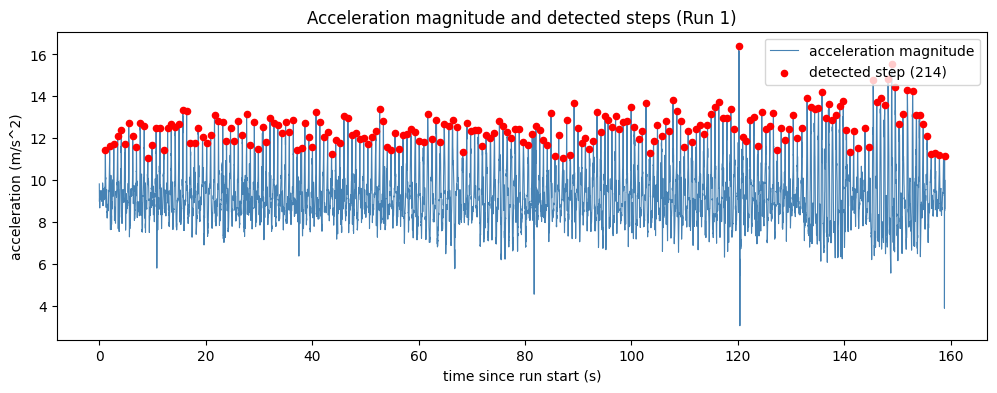

In [2]:
steps = imu.detect_steps(run.accel)
print("detected steps :", len(steps))
print("cadence        : %.2f steps/s" % (len(steps) / run.duration_s))

viz.plot_acceleration_with_steps(run.accel, steps, run_id=1)
plt.show()

## Evaluating step-detection accuracy


1. **Total count**: does the detected total match the counted total per run?
2. **Cumulative tracking**: does the detected count match the counted count *at
   every checkpoint*, so it tracks correctly throughout the walk.

### 1. Total-count accuracy

In [3]:
rows = []
for run_id in [1, 2, 3, 4]:
    r = preprocessing.load_run(run_id, raw_dir=RAW)
    detected = len(imu.detect_steps(r.accel))
    counted = int(evaluation.load_reference(run_id, reference_file=REF).iloc[-1]["sum_steps"])
    error = detected - counted
    rows.append({"run": run_id, "detected": detected, "counted": counted,
                 "error": error, "pct_error": round(100 * error / counted, 1)})

totals = pd.DataFrame(rows)
print("mean absolute total error: %.1f%%" % totals["pct_error"].abs().mean())
totals

mean absolute total error: 1.4%


,run,detected,counted,error,pct_error
0,1,214,216,-2,-0.9
1,2,231,238,-7,-2.9
2,3,335,340,-5,-1.5
3,4,281,282,-1,-0.4


### 2. Cumulative tracking

The detected cumulative step curve should pass through the counted reference
markers. Any drift between detection and ground truth would show up as a growing
gap; here the curve stays on the markers for the whole run.

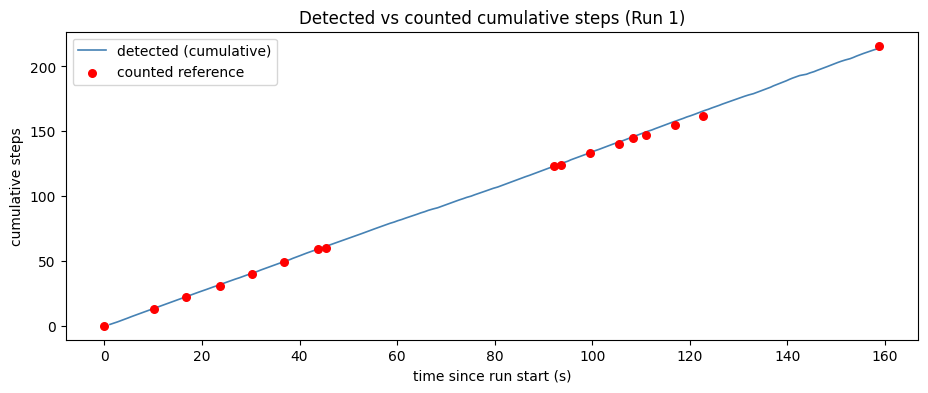

In [4]:
reference = evaluation.load_reference(1, reference_file=REF)
viz.plot_step_count_comparison(steps, reference, run_id=1)
plt.show()

In [5]:
def tracking_error(run_id):
    step_times = imu.detect_steps(preprocessing.load_run(run_id, raw_dir=RAW).accel)["t_rel"].values
    ref = evaluation.load_reference(run_id, reference_file=REF)
    abs_err, abs_pct = [], []
    for _, row in ref.iterrows():
        if row["t_rel"] is None or not row["sum_steps"]:
            continue
        detected_cumulative = int(np.sum(step_times <= row["t_rel"]))
        error = abs(detected_cumulative - row["sum_steps"])
        abs_err.append(error)
        abs_pct.append(100 * error / row["sum_steps"])
    return len(abs_err), np.mean(abs_err), np.mean(abs_pct)

rows = []
for run_id in [1, 2, 3, 4]:
    n, mae, mape = tracking_error(run_id)
    rows.append({"run": run_id, "checkpoints": n,
                 "mean_abs_err_steps": round(mae, 1),
                 "mean_abs_pct": round(mape, 1)})

tracking = pd.DataFrame(rows)
print("overall mean per-checkpoint error: %.1f steps (%.1f%%)"
      % (tracking["mean_abs_err_steps"].mean(), tracking["mean_abs_pct"].mean()))
tracking

overall mean per-checkpoint error: 2.3 steps (1.5%)


,run,checkpoints,mean_abs_err_steps,mean_abs_pct
0,1,16,0.8,0.5
1,2,16,2.9,2.5
2,3,23,3.3,1.6
3,4,24,2.2,1.6


**Result:** the step detector is accurate to within **~1.4% on the total count**
and **~1.6% per checkpoint** across all four runs — it tracks the counted steps
closely for the whole walk, which is what the motion model needs.

## Step length

The person's stride was measured at **65 cm**, kept as the constant

In [6]:
step_length_m = evaluation.STEP_LENGTH_M
print("step length          :", step_length_m, "m")
print("Run 1 total distance :", round(len(steps) * step_length_m, 1), "m")

step length          : 0.65 m
Run 1 total distance : 139.1 m


## Heading from the gyroscope

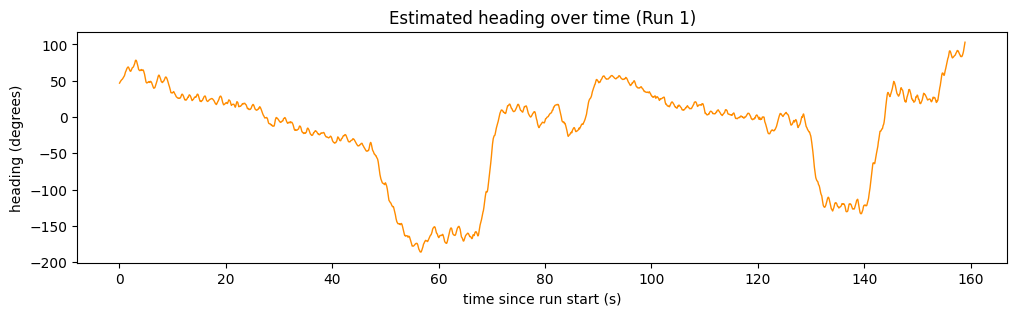

In [7]:
gravity = imu.estimate_gravity_direction(run.accel)
heading = imu.heading_from_gyro(run.gyro, gravity,
                                initial_heading=cfg["initial_heading"])

viz.plot_heading(heading, run_id=1)
plt.show()

## Per-step motion table

In [8]:
motion = imu.build_motion_table(run, initial_heading=cfg["initial_heading"])
motion.head()

,t_rel,step_length,heading,heading_sigma
0,1.136,0.65,1.064804,0.261799
1,1.942,0.65,1.131401,0.261799
2,2.722,0.65,1.218767,0.261799
3,3.452,0.65,1.254055,0.261799
4,4.134,0.65,1.140168,0.261799
